# ⚡ Model 08 — XGBoost (Baseline)

Extreme Gradient Boosting on balanced data.


--- MODEL EVALUATION ---
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    113975
           1       0.68      0.49      0.57      4133

    accuracy                           0.97    118108
   macro avg       0.83      0.74      0.78    118108
weighted avg       0.97      0.97      0.97    118108

ROC-AUC: 0.9108
PR-AUC: 0.5802


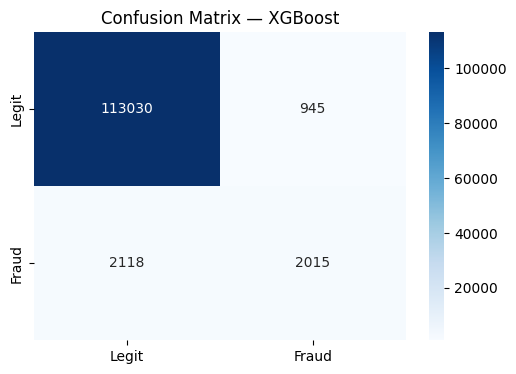

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_recall_curve, auc, confusion_matrix

# Load
train = pd.read_csv('../data/train_balanced.csv')
test = pd.read_csv('../data/test.csv')

X_train = train.drop(columns=['isFraud', 'TransactionID'], errors='ignore')
y_train = train['isFraud']
X_test = test.drop(columns=['isFraud', 'TransactionID'], errors='ignore')
y_test = test['isFraud']

# Train
model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, n_jobs=-1, random_state=42)
model.fit(X_train, y_train)

# Evaluate
probs = model.predict_proba(X_test)[:, 1]
preds = model.predict(X_test)

print("\n--- MODEL EVALUATION ---")
print(classification_report(y_test, preds))
print(f"ROC-AUC: {roc_auc_score(y_test, probs):.4f}")
precision, recall, _ = precision_recall_curve(y_test, probs)
print(f"PR-AUC: {auc(recall, precision):.4f}")

# Plot
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
plt.title('Confusion Matrix — XGBoost')
plt.show()